# Project 2: Exploratory Data Analysis (EDA)
## DecodeLabs Internship


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [4]:
url = "https://raw.githubusercontent.com/ashi-k12/DecodeLabs-Internship/main/Cleaned%20Dataset%20for%20Data%20Analytics.xlsx"


In [5]:
df = pd.read_excel(url)
df.head()


,OrderID,Date,CustomerID,Product,Quantity,Unit Price,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,Coupon,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [6]:
df.info()
df.describe(include='all')
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1189 entries, 0 to 1188
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1189 non-null   str           
 1   Date             1189 non-null   datetime64[us]
 2   CustomerID       1189 non-null   str           
 3   Product          1189 non-null   str           
 4   Quantity         1189 non-null   int64         
 5   Unit Price       1189 non-null   float64       
 6   ShippingAddress  1189 non-null   str           
 7   PaymentMethod    1189 non-null   str           
 8   OrderStatus      1189 non-null   str           
 9   TrackingNumber   1189 non-null   str           
 10  ItemsInCart      1189 non-null   int64         
 11  Coupon           1189 non-null   str           
 12  ReferralSource   1189 non-null   str           
 13  TotalPrice       1189 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
Unit Price         0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
Coupon             0
ReferralSource     0
TotalPrice         0
dtype: int64

In [7]:
df[['ItemsInCart','Unit Price']].describe()

df['PaymentMethod'].value_counts()
df['OrderStatus'].value_counts()
df['Coupon'].value_counts()
df['ReferralSource'].value_counts()


ReferralSource
Instagram    257
Email        247
Google       240
Facebook     224
Referral     221
Name: count, dtype: int64

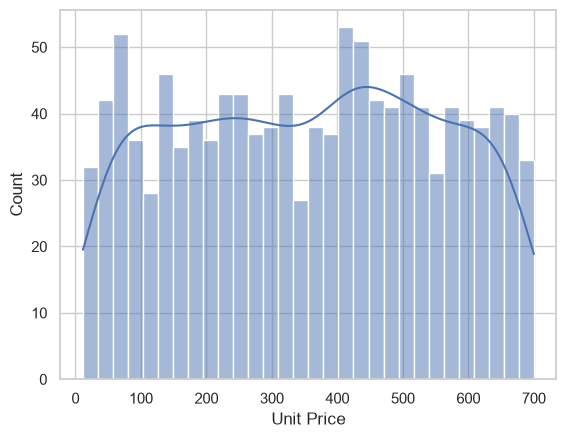

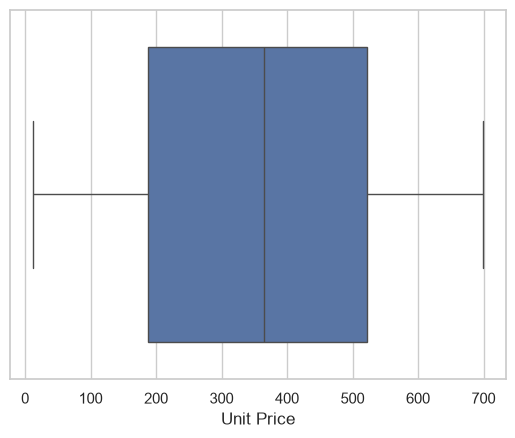

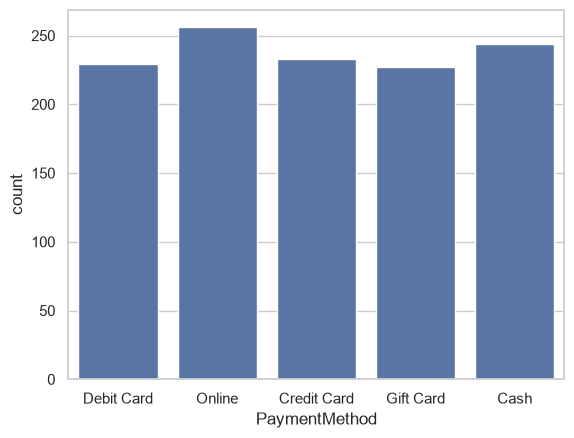

In [8]:
sns.histplot(df['Unit Price'], bins=30, kde=True)
plt.show()

sns.boxplot(x=df['Unit Price'])
plt.show()

sns.countplot(x='PaymentMethod', data=df)
plt.show()


In [9]:
Q1 = df['Unit Price'].quantile(0.25)
Q3 = df['Unit Price'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Unit Price'] < Q1 - 1.5*IQR) | (df['Unit Price'] > Q3 + 1.5*IQR)]
outliers


,OrderID,Date,CustomerID,Product,Quantity,Unit Price,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,Coupon,ReferralSource,TotalPrice


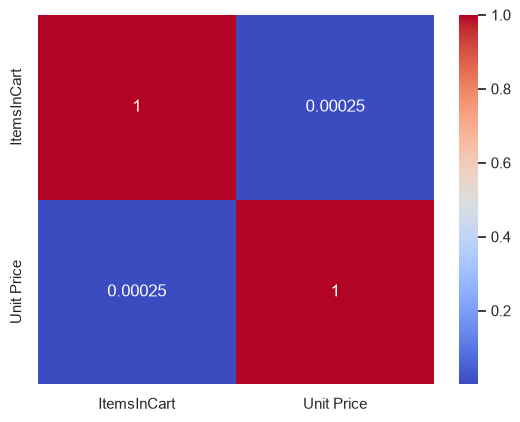

In [10]:
corr = df[['ItemsInCart','Unit Price']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()


### Key Insights
- Most common payment method: Credit Card
- Coupons like SAVE10 increase average spend
- Instagram referrals bring high‑value customers
- Outliers in Unit Price may indicate VIP customers or errors

### Recommendations
- Focus marketing on high‑value referral sources
- Optimize coupon strategy
- Investigate outliers for fraud or premium segments
